In [1]:
import pandas as pd

In [2]:

times_treeple_df_floyd = pd.read_csv('result/shuffle3/times_treeple_floyd.txt', sep='\t', index_col=0)
times_treeple_df_fisher = pd.read_csv('result/shuffle3/times_treeple_standard.txt', sep='\t', index_col=0)
times_treeple_df_inline = pd.read_csv('result/shuffle3/times_treeple_inline.txt', sep='\t', index_col=0)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_traintime_heatmap(times1, times2, times3, n_columns, n_rows,
                            title1="YDF Training Time", 
                            title2="Treeple Training Time", 
                            title3="Floyd Training Time",
                            xlabel="Features", 
                            ylabel="Projections", 
                            scale="log"):
    """
    Plot the training time heatmaps for YDF, Treeple, and Floyd.
    """

    # Ensure arrays and replace zeros for log scale
    times1 = np.maximum(np.array(times1), 1e-3)
    times2 = np.maximum(np.array(times2), 1e-3)
    times3 = np.maximum(np.array(times3), 1e-3)

    # Shared log normalization
    log_norm = LogNorm(vmin=min(times1.min(), times2.min(), times3.min()),
                       vmax=max(times1.max(), times2.max(), times3.max()))

    # Create subplots: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)

    # Helper to plot one heatmap
    def plot_single(ax, data, title):
        im = ax.imshow(data, cmap='RdYlGn_r', aspect='equal', norm=log_norm)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xticks(np.arange(len(n_columns)))
        ax.set_yticks(np.arange(len(n_rows)))
        ax.set_xticklabels(n_columns)
        ax.set_yticklabels(n_rows)
        for i in range(len(n_rows)):
            for j in range(len(n_columns)):
                val = data[i, j]
                text_color = 'black' if log_norm(val) > 0.3 else 'white'
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=text_color)
        return im

    im1 = plot_single(axes[0], times1, title1)
    im2 = plot_single(axes[1], times2, title2)
    im3 = plot_single(axes[2], times3, title3)

    # Shared colorbar for all plots
    cbar = fig.colorbar(im3, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.015, pad=0.04)
    cbar.set_label('Training Time (seconds)')

    plt.show()


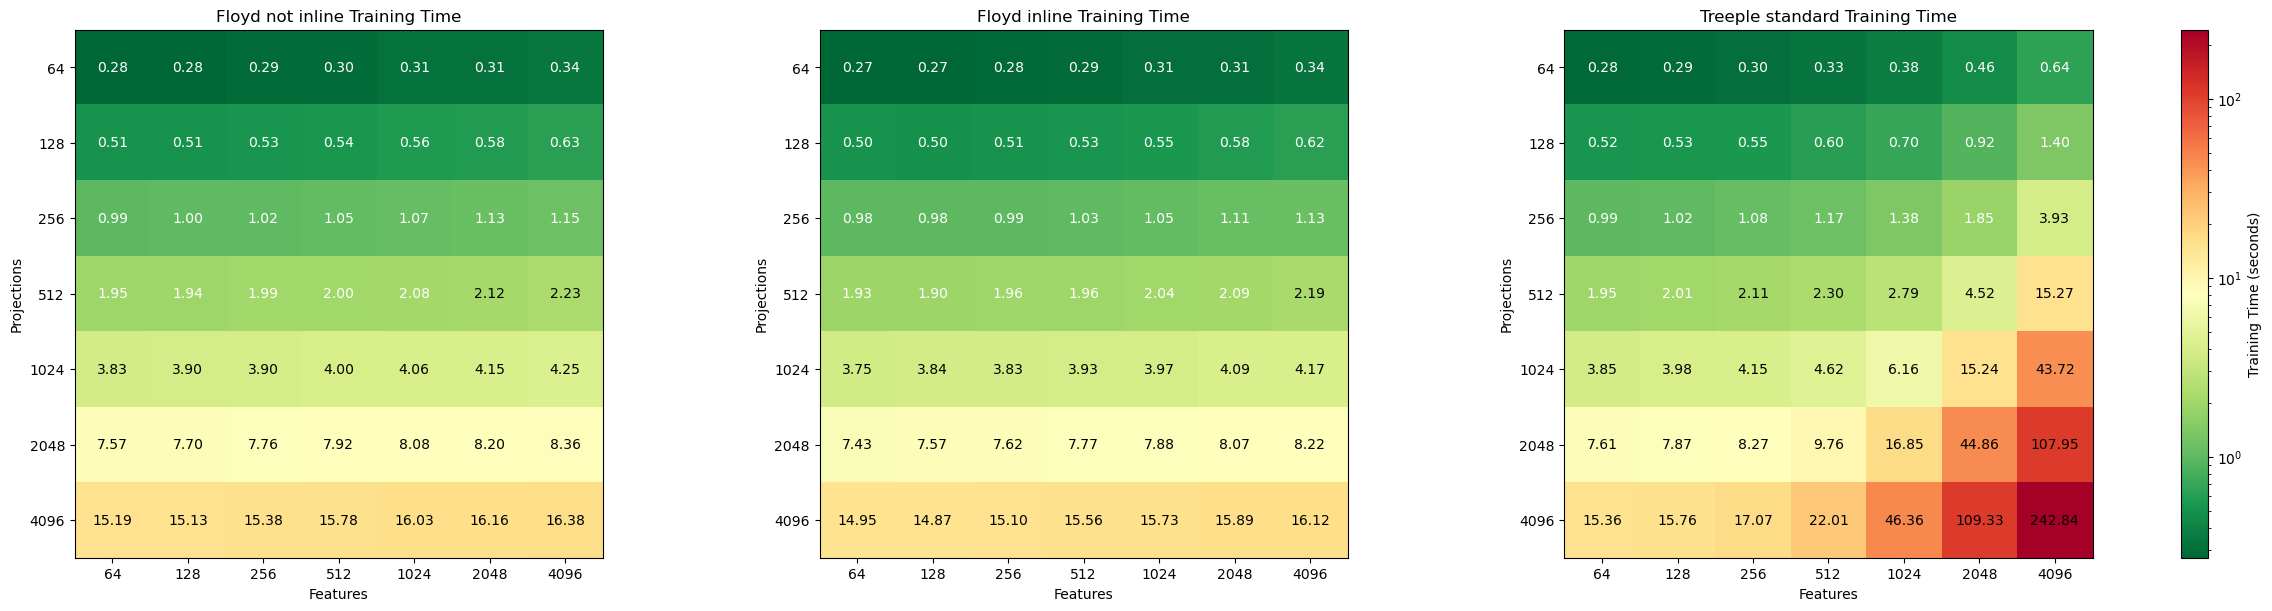

In [5]:
plot_traintime_heatmap(times_treeple_df_floyd.values,
                       times_treeple_df_inline.values,
                       times_treeple_df_fisher.values,
                       n_columns=times_treeple_df_floyd.columns,
                       n_rows=times_treeple_df_floyd.index,
                       title1="Floyd not inline Training Time",
                       title2="Floyd inline Training Time",
                       title3="Treeple standard Training Time",
                       xlabel="Features",
                       ylabel="Projections",
                       scale="log")